# Demonstration of theta-restriction in `mhn`

This demo illustrates the usage of the 'set_restriction' method in the Optimizer class

### Prerequisites 

This notebook assumes the usage of the local mhn-implementation (accessible via `pip install -e .`)

### Preparations
The following code largely matches the procedure presented in the normal mhn-demo `demo.ipynb`.
For simplicity's sake we don't make use of cross-validation here.

c:\Users\michi\Uni\SHK_Spang\learnmhn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Cross-Validation Folds: 100%|██████████| 3/3 [00:20<00:00,  6.84s/it]


Lambda scores:    Lambda Value  Mean Score  Standard Error
0      0.000200   -4.283961        0.104415
1      0.001125   -4.103779        0.057232
2      0.006325   -4.062723        0.054691
3      0.035566   -4.262427        0.040673
4      0.200000   -4.531384        0.032705


(<matplotlib.image.AxesImage at 0x1b285cab750>,
 <matplotlib.image.AxesImage at 0x1b284d9aa10>)

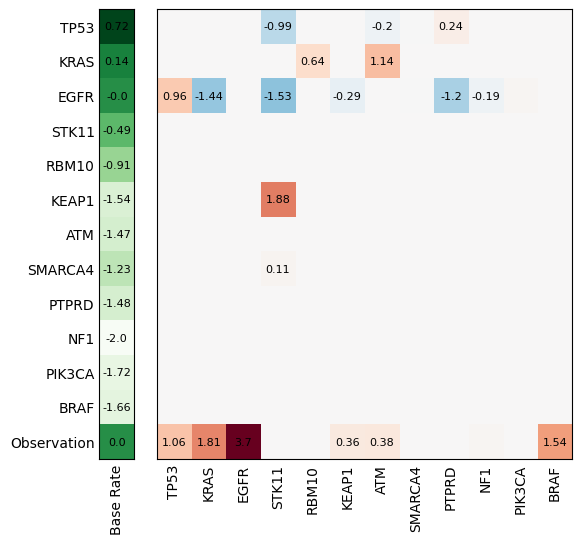

In [1]:
# preparations as in 'demo.ipynb' (excluding cross-validation)

import mhn
from mhn.optimizers import Optimizer
import pandas as pd
import random
import numpy as np
input = pd.read_csv('LUAD_n12.csv')
n=len(input.columns)

input_subset = input.sample(n=500, random_state=6)
opt = Optimizer()
opt.load_data_matrix(input_subset)
opt.set_penalty(opt.Penalty.L1)

lambda_min = 0.1/len(input_subset)
lambda_max = 100/len(input_subset)

np.random.seed(123)
opt_lam, lambda_scores = opt.lambda_from_cv(
    lambda_min=lambda_min, lambda_max=lambda_max, steps=5, nfolds=3, show_progressbar=True, return_lambda_scores=True)

print(f"Lambda scores: {lambda_scores}")

opt.train(lam=opt_lam)
opt.result.plot(colorbar=False)



## Restricting theta during training

Using the `set_restriction` method requires you to specify a restriction mask consisting of 0s and 1s. This is a matrix matching the shape of theta. 

 1 means this entry will be subject to changes during training (normal behavior)
 
 0 means this entry will remain unaltered during training

In [2]:
restriction_mask=np.ones((n+1,n))   #as we are using oMHN by default, the matrix shape needs to be ((n+1)xn)
restriction_mask[:,4:8]=0

np.fill_diagonal(restriction_mask,1)    #make sure diagonal entries (=baserates) are not getting restricted
restriction_mask[-1]=1                #make sure bottom row (=observation rates) are not getting restricted
opt.set_restriction(restriction_mask=restriction_mask)

print(restriction_mask)

[[1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


After setting a restriction the training procedure can be continued as usual..
To indicate the restricted theta entries in the resulting MHN's plot you may use the `overlay_restriction_mask` argument of the `plot` method.

(<matplotlib.image.AxesImage at 0x1b288139ad0>,
 <matplotlib.image.AxesImage at 0x1b288147b50>)

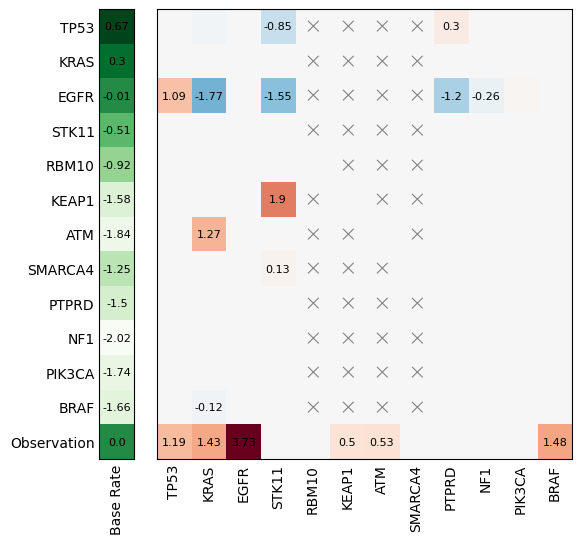

In [3]:
opt.train(lam=opt_lam)
opt.result.save("test_save.csv")
opt.result.plot(overlay_restriction_mask=True, colorbar=False)

## Restrictions for non-default init_theta
You are able to restrict log-theta entries to take on arbitrary values by setting `init_theta`. In the following we show an example of forcing 'ATM' to have a strong negative effect on 'EGFR'. 

In [4]:
from mhn.training.state_containers import create_indep_model

def default_omhn_init_theta(oMHN_opt):
    vanilla_theta = create_indep_model(oMHN_opt._data)
    n = vanilla_theta.shape[0]
    omega_theta = np.zeros((n + 1, n))
    omega_theta[:n] = vanilla_theta
    return omega_theta

[[-0.31  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   -0.71  0.    0.    2.    0.    0.   -2.    0.    0.    0.    0.  ]
 [ 0.    0.   -0.91  0.    2.    0.    0.   -2.    0.    0.    0.    0.  ]
 [ 0.    0.    0.   -1.73  0.    0.    0.   -2.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.   -2.11  0.    0.   -2.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.   -2.24  0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   -2.68  0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.   -2.44  0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.   -2.72  0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.   -3.23  0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -2.94  0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -2.86]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]]


Cross-Validation Folds: 100%|██████████| 3/3 [00:17<00:00,  5.89s/it]


Lambda scores:    Lambda Value  Mean Score  Standard Error
0      0.000200   -4.202122        0.071749
1      0.001125   -4.118655        0.066440
2      0.006325   -4.098470        0.051444
3      0.035566   -4.318517        0.042383
4      0.200000   -4.604523        0.034178


(<matplotlib.image.AxesImage at 0x1b28817a710>,
 <matplotlib.image.AxesImage at 0x1b2882d1a50>)

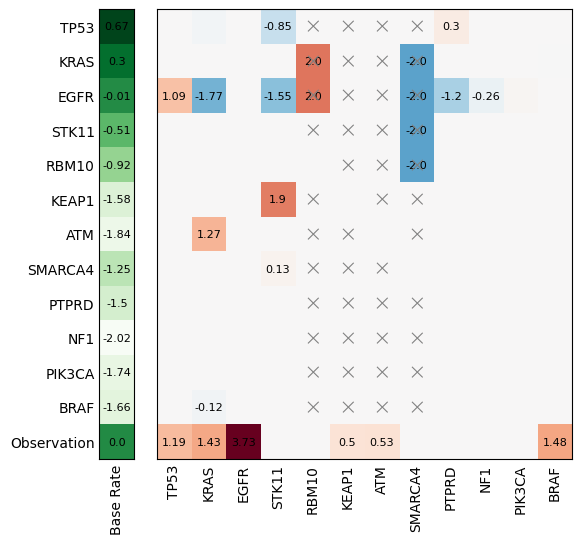

In [5]:
#preparations
opt2 = Optimizer()
opt2.load_data_matrix(input_subset)
opt2.set_penalty(opt2.Penalty.L1)

#setting init_theta
init_theta=default_omhn_init_theta(opt2)

init_theta[1:3,4]=2              
init_theta[1:5,7]=-2            
print(init_theta)
opt2.set_init_theta(init_theta)

#setting restriction
opt2.set_restriction(restriction_mask)

#training
np.random.seed(123)
opt_lam2, lambda_scores2 = opt2.lambda_from_cv(
    lambda_min=lambda_min, lambda_max=lambda_max, steps=5, nfolds=3, show_progressbar=True, return_lambda_scores=True)

print(f"Lambda scores: {lambda_scores2}")
opt2.train(opt_lam2)

#results
opt2.result.save("test2_save.csv")
opt2.result.plot(colorbar=False)
